# 📧 Modelado de Uplift – Entendimiento del Negocio y EDA

## Objetivo

El objetivo de este proyecto es optimizar campañas de email mediante técnicas de machine learning causal (uplift modeling).

A diferencia de un problema tradicional de clasificación, aquí no buscamos predecir quién comprará, sino estimar el impacto incremental del email sobre cada cliente.

## Pregunta clave

¿A qué clientes conviene enviar un email para maximizar conversiones e ingresos incrementales?

## Enfoque

Se utilizará el Hillstrom Email Marketing Dataset, que corresponde a un experimento controlado, lo que permite estimar efectos causales.

En este notebook se realizará:
- carga y limpieza de datos
- análisis exploratorio
- validación del diseño experimental
- primeros insights de uplift

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')

In [6]:
ruta = r"C:\Users\sebas\OneDrive\Desktop\Proyecto Chatbot\Opti-Correos\hillstrom.csv"

df = pd.read_csv(ruta)

df.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   recency          64000 non-null  int64  
 1   history_segment  64000 non-null  str    
 2   history          64000 non-null  float64
 3   mens             64000 non-null  int64  
 4   womens           64000 non-null  int64  
 5   zip_code         64000 non-null  str    
 6   newbie           64000 non-null  int64  
 7   channel          64000 non-null  str    
 8   segment          64000 non-null  str    
 9   visit            64000 non-null  int64  
 10  conversion       64000 non-null  int64  
 11  spend            64000 non-null  float64
dtypes: float64(2), int64(6), str(4)
memory usage: 5.9 MB


In [9]:
df.shape

(64000, 12)

In [10]:
df.describe()

,recency,history,mens,womens,newbie,visit,conversion,spend
count,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000
mean,5.763734,242.085656,0.551031,0.549719,0.502250,0.146781,0.009031,1.050908
std,3.507592,256.158608,0.497393,0.497526,0.499999,0.353890,0.094604,15.036448
min,1.000000,29.990000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,64.660000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,6.000000,158.110000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,9.000000,325.657500,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
max,12.000000,3345.930000,1.000000,1.000000,1.000000,1.000000,1.000000,499.000000


In [11]:
df.isnull().sum().sort_values(ascending=False)

recency            0
history_segment    0
history            0
mens               0
womens             0
zip_code           0
newbie             0
channel            0
segment            0
visit              0
conversion         0
spend              0
dtype: int64

In [12]:
df['tratamiento'] = df['segment'].apply(lambda x: 0 if x == 'No E-Mail' else 1)

df['conversion_binaria'] = df['conversion']
df['visita_binaria'] = df['visit']

In [13]:
df[['segment', 'tratamiento']].head()

,segment,tratamiento
0,Womens E-Mail,1
1,No E-Mail,0
2,Womens E-Mail,1
3,Mens E-Mail,1
4,Womens E-Mail,1


In [14]:
df['segment'].value_counts(normalize=True)

segment
Womens E-Mail    0.334172
Mens E-Mail      0.332922
No E-Mail        0.332906
Name: proportion, dtype: float64

In [16]:
df.groupby('segment').size()

segment
Mens E-Mail      21307
No E-Mail        21306
Womens E-Mail    21387
dtype: int64

In [17]:
conversion_por_grupo = df.groupby('segment')['conversion_binaria'].mean()
conversion_por_grupo

segment
Mens E-Mail      0.012531
No E-Mail        0.005726
Womens E-Mail    0.008837
Name: conversion_binaria, dtype: float64

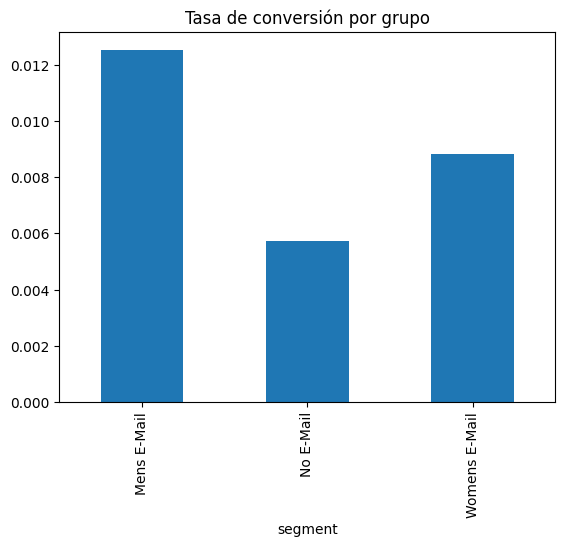

In [18]:
conversion_por_grupo.plot(kind='bar')
plt.title("Tasa de conversión por grupo")
plt.show()

In [19]:
visitas_por_grupo = df.groupby('segment')['visita_binaria'].mean()
visitas_por_grupo

segment
Mens E-Mail      0.182757
No E-Mail        0.106167
Womens E-Mail    0.151400
Name: visita_binaria, dtype: float64

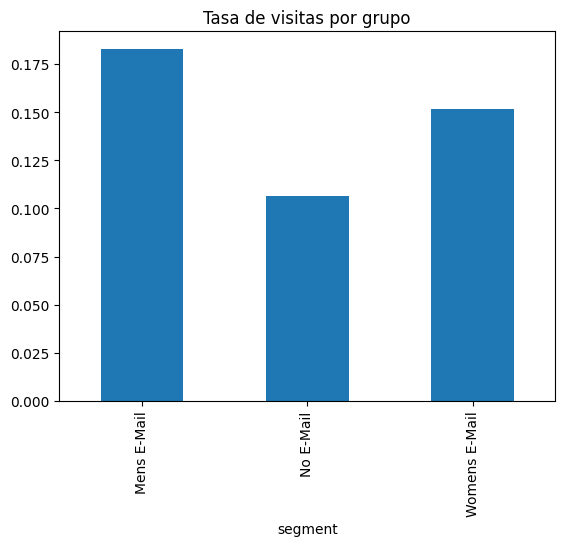

In [20]:
visitas_por_grupo.plot(kind='bar')
plt.title("Tasa de visitas por grupo")
plt.show()

In [21]:
gasto_por_grupo = df.groupby('segment')['spend'].mean()
gasto_por_grupo

segment
Mens E-Mail      1.422617
No E-Mail        0.652789
Womens E-Mail    1.077202
Name: spend, dtype: float64

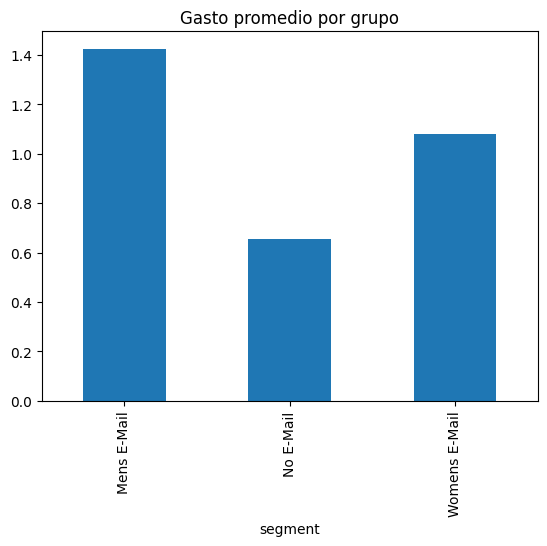

In [22]:
gasto_por_grupo.plot(kind='bar')
plt.title("Gasto promedio por grupo")
plt.show()

In [23]:
tratados = df[df['tratamiento'] == 1]
control = df[df['tratamiento'] == 0]

uplift_promedio = tratados['conversion_binaria'].mean() - control['conversion_binaria'].mean()

uplift_promedio

np.float64(0.004954571155268468)

In [24]:
uplift_por_historial = df.groupby('history_segment').apply(
    lambda x: x[x['tratamiento']==1]['conversion_binaria'].mean() - 
              x[x['tratamiento']==0]['conversion_binaria'].mean()
)

uplift_por_historial.sort_values()

history_segment
4) $350 - $500      0.003170
3) $200 - $350      0.003871
2) $100 - $200      0.004253
1) $0 - $100        0.004391
5) $500 - $750      0.009281
7) $1,000 +         0.010241
6) $750 - $1,000    0.014579
dtype: float64

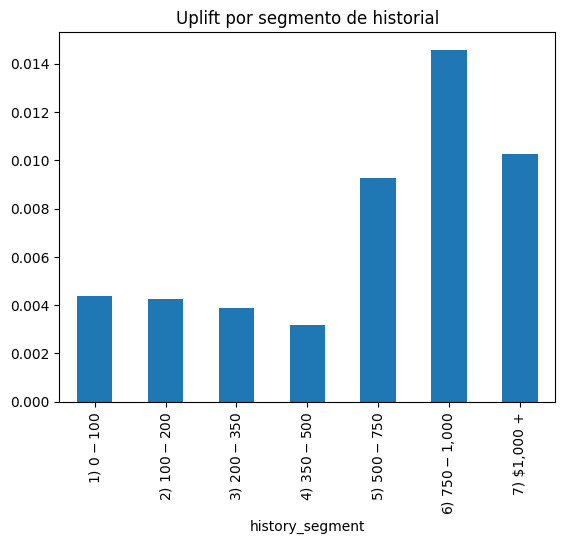

In [25]:
uplift_por_historial.plot(kind='bar')
plt.title("Uplift por segmento de historial")
plt.show()

## Principales insights

- Existe diferencia observable entre grupos tratados y control, lo que valida el efecto del tratamiento.
- El uplift promedio es positivo, pero no homogéneo.
- Algunos segmentos presentan mayor sensibilidad al email.
- Esto sugiere que una estrategia de targeting puede mejorar significativamente los resultados.

## Implicación

No todos los clientes deben recibir el email. Existe oportunidad de optimizar la campaña mediante selección inteligente.